In [ ]:
import numpy as np
import pandas as pd

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(r'/content/drive/MyDrive/Data Science /DL_Datasets/my_dataframe.csv')

### Keep Required Columns

In [ ]:
df = df[["Document", "Topic_group"]]

df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


### Encode Labels

In [ ]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["Topic_group"])

In [ ]:
df.head(2)

,Document,Topic_group,label
0,connection with icon icon dear please setup ic...,Hardware,3
1,work experience user work experience user hi w...,Access,0


### Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["Document"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

### Create DataFrames

In [ ]:
train_df = pd.DataFrame({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

test_df = pd.DataFrame({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

### Convert to Hugging Face Dataset

In [ ]:
train_dataset = Dataset.from_pandas(train_df)

test_dataset = Dataset.from_pandas(test_df)

In [ ]:
print(train_dataset[0])

{'text': 'projects not open for pas forecast sent thursday projects open for forecast hi could you please investigate reason why projects open for forecasting either for or thank you sent thursday open for forecasting budget dear please be informed open for forecast period version budgeting final version please be mindful about point view you should be using during cycle snapshot below please feel free circulate your teams necessary thank you regards', 'label': 3}


In [ ]:
print(train_dataset[0])

print(train_dataset.features)

{'text': 'projects not open for pas forecast sent thursday projects open for forecast hi could you please investigate reason why projects open for forecasting either for or thank you sent thursday open for forecasting budget dear please be informed open for forecast period version budgeting final version please be mindful about point view you should be using during cycle snapshot below please feel free circulate your teams necessary thank you regards', 'label': 3}
{'text': Value('string'), 'label': Value('int64')}


# Phase 2 — BERT Tokenization

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### Tokenization Function

In [ ]:
def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=300
    )

### Tokenize Dataset

In [ ]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/38269 [00:00<?, ? examples/s]

Map:   0%|          | 0/9568 [00:00<?, ? examples/s]

In [ ]:
print(train_dataset[0])

{'text': 'projects not open for pas forecast sent thursday projects open for forecast hi could you please investigate reason why projects open for forecasting either for or thank you sent thursday open for forecasting budget dear please be informed open for forecast period version budgeting final version please be mindful about point view you should be using during cycle snapshot below please feel free circulate your teams necessary thank you regards', 'label': 3, 'input_ids': [101, 3934, 2025, 2330, 2005, 14674, 19939, 2741, 9432, 3934, 2330, 2005, 19939, 7632, 2071, 2017, 3531, 8556, 3114, 2339, 3934, 2330, 2005, 19939, 2075, 2593, 2005, 2030, 4067, 2017, 2741, 9432, 2330, 2005, 19939, 2075, 5166, 6203, 3531, 2022, 6727, 2330, 2005, 19939, 2558, 2544, 5166, 2075, 2345, 2544, 3531, 2022, 2568, 3993, 2055, 2391, 3193, 2017, 2323, 2022, 2478, 2076, 5402, 20057, 12326, 2917, 3531, 2514, 2489, 25022, 11890, 9869, 2115, 2780, 4072, 4067, 2017, 12362, 102], 'token_type_ids': [0, 0, 0, 0, 0,

### Dynamic Padding

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
print(train_dataset[0].keys())

dict_keys(['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])


# Phase 3 — Load BERT Model

In [ ]:
from transformers import AutoModelForSequenceClassification

NUM_CLASSES = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=NUM_CLASSES
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
print(model.config.num_labels)

8


### Metrics Function

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### Training Arguments

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./bert_output",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    logging_steps=100,

    report_to="none"
)

### Trainer

In [ ]:
from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,


    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [ ]:
pip install transformers==4.55.4

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.405700,0.386107,0.871342,0.873140,0.871342,0.871327
2,0.272300,0.379005,0.878240,0.879389,0.878240,0.878064
3,0.185600,0.400350,0.886183,0.886470,0.886183,0.886189


TrainOutput(global_step=7176, training_loss=0.35948602185733075, metrics={'train_runtime': 4165.5553, 'train_samples_per_second': 27.561, 'train_steps_per_second': 1.723, 'total_flos': 1.027760465778576e+16, 'train_loss': 0.35948602185733075, 'epoch': 3.0})

### Evaluate

In [ ]:
results = trainer.evaluate()

print(results)

{'eval_loss': 0.4003501534461975, 'eval_accuracy': 0.886183110367893, 'eval_precision': 0.8864695941840327, 'eval_recall': 0.886183110367893, 'eval_f1': 0.8861894360006674, 'eval_runtime': 115.0485, 'eval_samples_per_second': 83.165, 'eval_steps_per_second': 5.198, 'epoch': 3.0}


### Predictions

In [ ]:
predictions = trainer.predict(test_dataset)

### Convert to Labels

In [ ]:
import numpy as np

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

### Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                       precision    recall  f1-score   support

               Access       0.90      0.93      0.91      1425
Administrative rights       0.85      0.79      0.82       352
           HR Support       0.91      0.89      0.90      2183
             Hardware       0.87      0.88      0.88      2724
     Internal Project       0.89      0.88      0.89       424
        Miscellaneous       0.84      0.87      0.86      1412
             Purchase       0.95      0.91      0.93       493
              Storage       0.90      0.90      0.90       555

             accuracy                           0.89      9568
            macro avg       0.89      0.88      0.89      9568
         weighted avg       0.89      0.89      0.89      9568



### Confusion Matrix

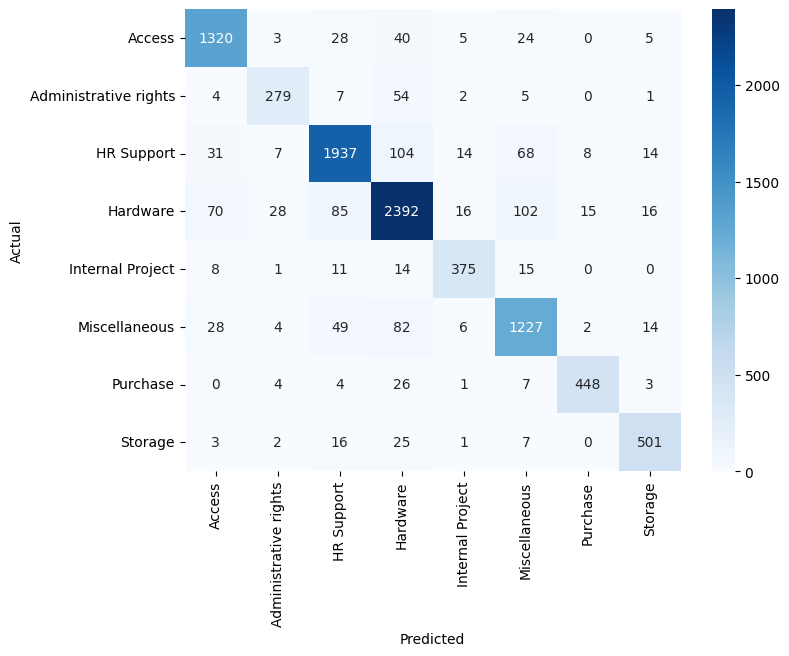

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Save Everything
- Save the model:

In [ ]:
trainer.save_model("bert_ticket_classifier")

- Save the tokenizer:

In [ ]:
tokenizer.save_pretrained("bert_ticket_classifier")

('bert_ticket_classifier/tokenizer_config.json',
 'bert_ticket_classifier/special_tokens_map.json',
 'bert_ticket_classifier/vocab.txt',
 'bert_ticket_classifier/added_tokens.json',
 'bert_ticket_classifier/tokenizer.json')

- Save the label encoder:

In [ ]:
import pickle

with open("label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder,f)

In [ ]:
import shutil

shutil.make_archive(
    "bert_ticket_classifier",
    "zip",
    "bert_ticket_classifier"
)

'/content/bert_ticket_classifier.zip'

In [ ]:
from google.colab import files

files.download("bert_ticket_classifier.zip")
# files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('bert_ticket_classifier')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.path.exists("bert_ticket_classifier.zip"))

True
